# Validacao da base longa de visualizacoes

Este notebook testa se `base_long_visualizacoes_pib.xlsx` contem as informacoes necessarias para reconstruir os componentes do painel de PIB total e PIB per capita. Os testes usam somente a base longa.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

project_dir = Path.cwd()
if not (project_dir / 'Dados').exists():
    project_dir = project_dir.parent
base_path = project_dir / 'Dados' / 'Processado' / 'base_long_visualizacoes_pib.xlsx'

df = pd.read_excel(base_path, sheet_name='base_long')
df['data'] = pd.to_datetime(df['data'])
print(f'Arquivo: {base_path}')
print(f'Linhas: {len(df):,}'.replace(',', '.'))
df.head()

Arquivo: C:\Users\joao-giorio\Desktop\Painel PIB Municípios\Dados\Processado\base_long_visualizacoes_pib.xlsx
Linhas: 37.312


,data,variavel,territorio,componente,nivel_geo,valor
0,2023-01-01,Contribuição ao crescimento - PIB per capita,Alto Uruguai Catarinense,Contribuição ao crescimento,Estado,0.000484
1,2024-01-01,Contribuição ao crescimento - PIB per capita,Alto Uruguai Catarinense,Contribuição ao crescimento,Estado,-0.000282
2,2025-01-01,Contribuição ao crescimento - PIB per capita,Alto Uruguai Catarinense,Contribuição ao crescimento,Estado,0.000190
3,2023-01-01,Contribuição ao crescimento - PIB per capita,Alto Vale do Itajaí,Contribuição ao crescimento,Estado,-0.000599
4,2024-01-01,Contribuição ao crescimento - PIB per capita,Alto Vale do Itajaí,Contribuição ao crescimento,Estado,0.000500


In [2]:
# Estrutura e cobertura dos componentes
expected_columns = ['data', 'variavel', 'territorio', 'componente', 'nivel_geo', 'valor']
expected_components = {
    'Mapa',
    'Ranking de vice-presid\u00eancias',
    'Ranking Municipal',
    'Evolu\u00e7\u00e3o do PIB',
    'Visualiza\u00e7\u00f5es de Crescimento',
    'Contribui\u00e7\u00e3o ao crescimento',
}
expected_levels = {'Estado', 'Vice-presid\u00eancia', 'Munic\u00edpio'}

assert df.columns.tolist() == expected_columns
assert df.isna().sum().sum() == 0
assert set(df['componente']) == expected_components
assert set(df['nivel_geo']) == expected_levels

coverage = df.groupby(['componente', 'nivel_geo']).size().rename('linhas').to_frame()
display(coverage)
print('Estrutura, componentes e niveis geograficos: OK')

linhas
componente                   nivel_geo               
Contribuição ao crescimento  Estado               187
                             Município           6490
                             Vice-presidência    3421
Evolução do PIB              Estado                11
                             Município           3245
                             Vice-presidência     176
Mapa                         Estado               704
                             Vice-presidência   12980
Ranking Municipal            Estado              3245
                             Vice-presidência    3245
Ranking de vice-presidências Estado               176
Visualizações de Crescimento Estado                11
                             Município           3245
                             Vice-presidência     176

Estrutura, componentes e niveis geograficos: OK


In [3]:
# Mapa: cada territorio tem PIB, participacao, crescimento e CAGR por ano.
mapa_estado_2025 = df.loc[
    (df['componente'] == 'Mapa')
    & (df['nivel_geo'] == 'Estado')
    & (df['data'].dt.year == 2025)
    & (df['variavel'].isin(['PIB total', 'Participacao - PIB total', 'Crescimento anual - PIB total', 'CAGR 2023-2030 - PIB total'])),
].pivot(index='territorio', columns='variavel', values='valor')

assert len(mapa_estado_2025) == 16
assert mapa_estado_2025.columns.size == 4
display(mapa_estado_2025.head())
print('Mapa estadual por VP: OK')

variavel,CAGR 2023-2030 - PIB total,Crescimento anual - PIB total,PIB total,Participacao - PIB total
territorio,,,,
Alto Uruguai Catarinense,0.020532,0.018638,1.182807e+10,0.021118
Alto Vale do Itajaí,0.028392,0.024547,1.701932e+10,0.030387
Centro - Norte,0.016863,0.014524,2.535907e+10,0.045277
Centro - Oeste,0.021093,0.019011,1.536062e+10,0.027425
Extremo Oeste,0.024724,0.020725,1.754520e+10,0.031326


Mapa estadual por VP: OK


,territorio,valor,ranking
0,Foz do Rio Itajaí,1.297716e+11,1
1,Norte - Nordeste,1.002086e+11,2
2,Sudeste,8.517141e+10,3
3,Vale do Itajaí,4.960925e+10,4
4,Oeste,4.627892e+10,5


Rankings estadual, de VPs e municipal: OK


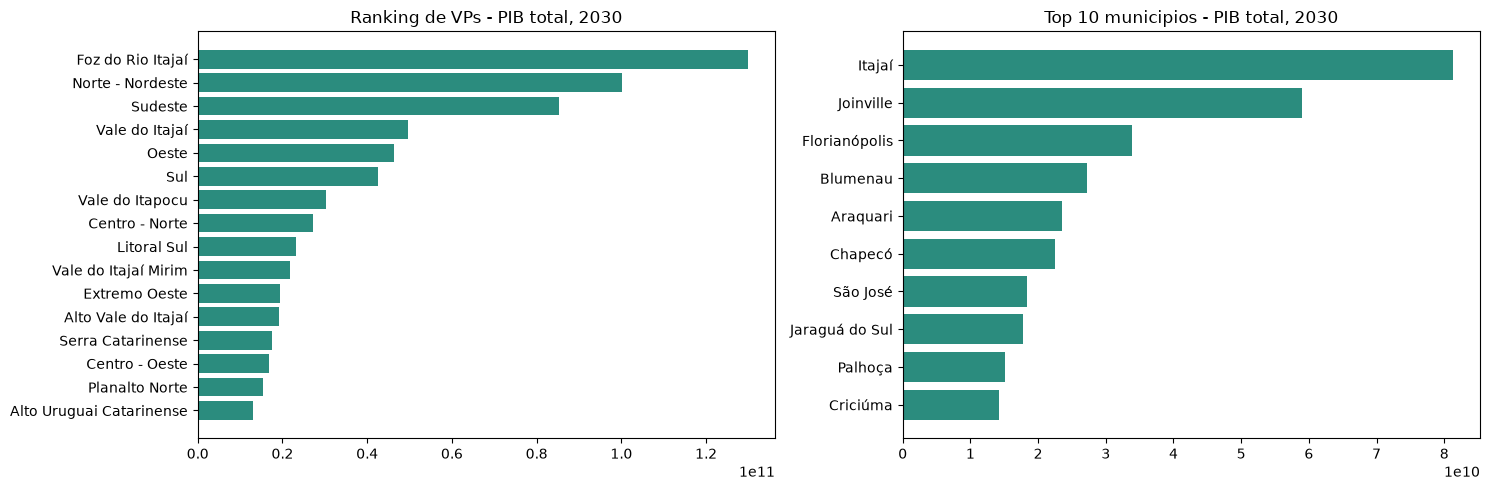

In [4]:
# Rankings: reproduzidos com ordenacao decrescente de valor no ano selecionado.
def ranking(component, level, variable, year):
    return (
        df.loc[
            (df['componente'] == component)
            & (df['nivel_geo'] == level)
            & (df['variavel'] == variable)
            & (df['data'].dt.year == year),
            ['territorio', 'valor'],
        ]
        .sort_values('valor', ascending=False, ignore_index=True)
        .assign(ranking=lambda data: data.index + 1)
    )

ranking_vps = ranking('Ranking de vice-presid\u00eancias', 'Estado', 'PIB total', 2030)
ranking_municipios_sc = ranking('Ranking Municipal', 'Estado', 'PIB total', 2030)
assert len(ranking_vps) == 16
assert len(ranking_municipios_sc) == 295

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(ranking_vps['territorio'], ranking_vps['valor'], color='#2b8c7e')
axes[0].invert_yaxis()
axes[0].set_title('Ranking de VPs - PIB total, 2030')
top10 = ranking_municipios_sc.head(10).sort_values('valor')
axes[1].barh(top10['territorio'], top10['valor'], color='#2b8c7e')
axes[1].set_title('Top 10 municipios - PIB total, 2030')
plt.tight_layout()
display(ranking_vps.head())
print('Rankings estadual, de VPs e municipal: OK')

Evolucao e crescimento anual: OK


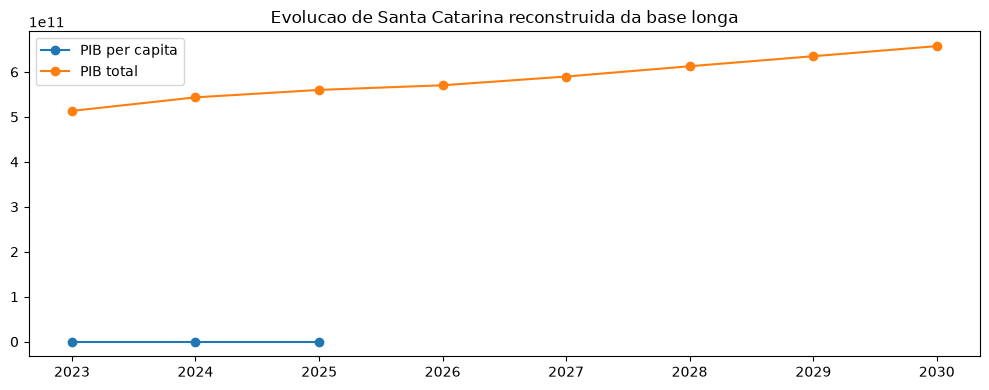

In [5]:
# Evolucao e visualizacao de crescimento: as duas abas e os tres niveis estao cobertos.
evolucao_sc = df.loc[
    (df['componente'] == 'Evolu\u00e7\u00e3o do PIB')
    & (df['nivel_geo'] == 'Estado')
    & (df['territorio'] == 'Santa Catarina'),
    ['data', 'variavel', 'valor'],
].sort_values(['variavel', 'data'])
crescimento = df.loc[df['componente'] == 'Visualiza\u00e7\u00f5es de Crescimento']

assert set(crescimento['variavel']) == {'Crescimento anual - PIB total', 'Crescimento anual - PIB per capita'}
assert not crescimento['variavel'].str.contains('CAGR|Base', case=False, regex=True).any()
assert set(evolucao_sc[evolucao_sc['variavel'] == 'PIB total']['data'].dt.year) == set(range(2023, 2031))
assert set(evolucao_sc[evolucao_sc['variavel'] == 'PIB per capita']['data'].dt.year) == {2023, 2024, 2025}

fig, ax = plt.subplots(figsize=(10, 4))
for variable, values in evolucao_sc.groupby('variavel'):
    ax.plot(values['data'], values['valor'], marker='o', label=variable)
ax.set_title('Evolucao de Santa Catarina reconstruida da base longa')
ax.legend()
plt.tight_layout()
print('Evolucao e crescimento anual: OK')

In [6]:
# Contribuicoes: a soma dos componentes deve fechar a taxa de crescimento de referencia.
component = 'Contribui\u00e7\u00e3o ao crescimento'
metrics = ['PIB total', 'PIB per capita']
checks = []

for metric in metrics:
    contributions = df.loc[
        (df['componente'] == component)
        & (df['nivel_geo'] == 'Estado')
        & (df['variavel'] == f'Contribui\u00e7\u00e3o ao crescimento - {metric}'),
    ]
    expected = df.loc[
        (df['componente'] == component)
        & (df['nivel_geo'] == 'Estado')
        & (df['territorio'] == 'Santa Catarina')
        & (df['variavel'] == f'Crescimento anual - {metric}'),
        ['data', 'valor'],
    ].rename(columns={'valor': 'crescimento'})
    observed = contributions.groupby('data', as_index=False)['valor'].sum().rename(columns={'valor': 'soma_contribuicoes'})
    check = observed.merge(expected, on='data')
    check['erro_absoluto'] = (check['soma_contribuicoes'] - check['crescimento']).abs()
    assert check['erro_absoluto'].max() < 1e-10
    check['medida'] = metric
    checks.append(check)

checks = pd.concat(checks, ignore_index=True)
display(checks)

vp_contributions = df.loc[
    (df['componente'] == component)
    & (df['nivel_geo'] == 'Vice-presid\u00eancia')
    & df['variavel'].str.startswith('Contribui\u00e7\u00e3o ao crescimento - '),
]
assert not vp_contributions.empty
assert len(df.loc[(df['componente'] == component) & (df['nivel_geo'] == 'Munic\u00edpio')]) == 295 * 2 * 11
print('Contribuicoes estadual, por VP e municipal: OK')

,data,soma_contribuicoes,crescimento,erro_absoluto,medida
0,2023-01-01,0.004971,0.004971,1.231654e-16,PIB total
1,2024-01-01,0.058647,0.058647,4.024558e-16,PIB total
2,2025-01-01,0.030516,0.030516,6.938894e-17,PIB total
3,2026-01-01,0.018435,0.018435,7.667478e-16,PIB total
4,2027-01-01,0.034003,0.034003,1.734723e-16,PIB total
5,2028-01-01,0.038792,0.038792,2.012279e-16,PIB total
6,2029-01-01,0.036508,0.036508,5.620504e-16,PIB total
7,2030-01-01,0.035393,0.035393,1.262879e-15,PIB total
8,2023-01-01,-0.021228,-0.021228,1.734723e-17,PIB per capita
9,2024-01-01,0.022241,0.022241,4.093947e-16,PIB per capita


Contribuicoes estadual, por VP e municipal: OK


## Conclusao

Se todas as celulas acima forem executadas sem erro, a base longa contem os dados para reproduzir os componentes do painel. O ranking e derivado por ordenacao; o agrupamento `Outros` da contribuicao de VP e derivado em tempo de visualizacao pela soma dos municipios fora dos seis maiores contribuintes de cada ano.